Name: Premanshu Devendra Kusre  
Roll No: CS23117  
Subject: Machine Learning  
Topic: Network Anomaly Detection  
Dataset: UNSW-NB15  
Model Used: K-Nearest Neighbors (KNN)

AIM

To implement the K-Nearest Neighbors (KNN) algorithm on the UNSW-NB15 dataset
for detecting network anomalies and classifying network traffic.

DATASET DESCRIPTION

The UNSW-NB15 dataset is a network intrusion detection dataset created by the Australian Centre for Cyber Security.

It contains modern network traffic with both normal activities and malicious attacks.

The dataset includes various network flow features such as protocol, service, source bytes, destination bytes, packets, TTL values, etc.

The target variable is 'label': 0 → Normal traffic 1 → Attack / anomaly

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
# Load dataset

df = pd.read_csv("/content/drive/MyDrive/ML Dataset/UNSW_NB15_training-set.csv")

In [20]:
# Display first 5 rows
df.head()


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [21]:
df.shape

(82332, 45)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt             823

In [23]:
df['label'].value_counts()

,count
label,
1,45332
0,37000


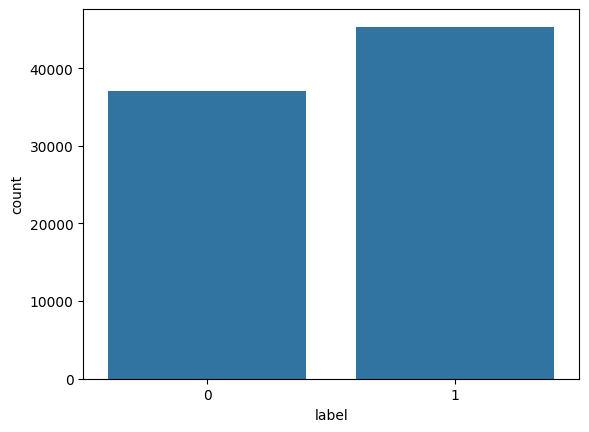

In [24]:
sns.countplot(x='label', data=df)
plt.show()

In [25]:
encoder = LabelEncoder()

df['proto'] = encoder.fit_transform(df['proto'])
df['service'] = encoder.fit_transform(df['service'])
df['state'] = encoder.fit_transform(df['state'])

In [26]:
df = df.drop(['attack_cat'], axis=1)

In [27]:
X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (65865, 43)
Testing shape: (16467, 43)


FEATURE SCALING

Feature scaling is essential for KNN because it is a distance-based algorithm.
Without scaling, features with larger values can dominate the distance calculation.

In [28]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

MODEL IMPLEMENTATION

K-Nearest Neighbors (KNN) is a distance-based algorithm that classifies
data points based on the majority class of their nearest neighbors.

In [35]:
knn_model = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

knn_model.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean')

In [30]:
y_pred = knn_model.predict(X_test)

In [31]:
accuracy = accuracy_score(y_test, y_pred)

print("KNN Accuracy: {:.2f}%".format(accuracy * 100))

KNN Accuracy: 97.61%


In [32]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[7261  157]
 [ 236 8813]]


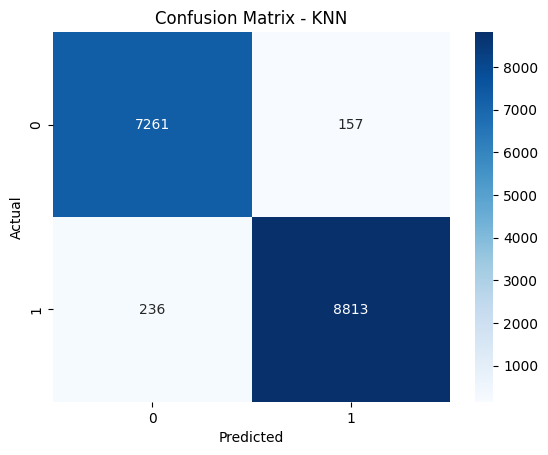

In [33]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      7418
           1       0.98      0.97      0.98      9049

    accuracy                           0.98     16467
   macro avg       0.98      0.98      0.98     16467
weighted avg       0.98      0.98      0.98     16467



RESULT

The KNN model was successfully implemented on the UNSW-NB15 dataset.

Feature scaling was applied to improve performance since KNN is a distance-based algorithm.
The model performed reasonably well but is slower compared to other models on large datasets.

KNN is simple and effective but sensitive to the choice of neighbors and feature scaling.